# Treinamento SVM - Classificação de Comportamento Canino
**Estratégia:** Leave-One-Subject-Out (LOSO)
**Objetivo:** Gerar métricas (Acurácia, Precision, Recall) e Matriz de Confusão.

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

repo_root = Path("../../").resolve() 
file_path = repo_root / "models" / "data" / "DogFeatures.csv"

print(f"Lendo dados de: {file_path}")

Lendo dados de: /mnt/c/Users/rishi/OneDrive/Área de Trabalho/ciencia de dados/classificacao-comportamento-canino-ine5687/models/data/DogFeatures.csv


In [2]:
if not file_path.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {file_path}")

df = pd.read_csv(file_path)

groups = df["DogID"]

cols_to_drop = ["DogID", "label", "Breed", "Gender", "NeuteringStatus", "TestNum", "t_dt"]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=cols_to_drop)
y = df["label"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)
target_names = le.classes_

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dados prontos. Features: {X.shape[1]}, Amostras: {X.shape[0]}, Cães: {len(np.unique(groups))}")

Dados prontos. Features: 74, Amostras: 57119, Cães: 45


In [3]:
print("Configurando SVM com Leave-One-Group-Out...")

logo = LeaveOneGroupOut()
svm = SVC()

param_grid = [
    {'C': [1, 10], 'kernel': ['linear']},
    {'C': [1, 10], 'kernel': ['rbf'], 'gamma': ['scale']}
]

grid_search = GridSearchCV(
    svm, 
    param_grid, 
    cv=logo, 
    scoring='accuracy', 
    verbose=3, 
    n_jobs=-1
)


Configurando SVM com Leave-One-Group-Out...


In [4]:
print("Iniciando treinamento...")
grid_search.fit(X_scaled, y_encoded, groups=groups)

print(f"Melhores Parâmetros: {grid_search.best_params_}")
print(f"Melhor Acurácia Média (LOSO): {grid_search.best_score_:.4f}")

Iniciando treinamento...
Fitting 45 folds for each of 4 candidates, totalling 180 fits
[CV 1/45] END ...............C=1, kernel=linear;, score=0.776 total time= 2.2min
[CV 5/45] END ...............C=1, kernel=linear;, score=0.798 total time= 2.2min
[CV 2/45] END ...............C=1, kernel=linear;, score=0.972 total time= 2.3min
[CV 4/45] END ...............C=1, kernel=linear;, score=0.932 total time= 2.3min
[CV 8/45] END ...............C=1, kernel=linear;, score=0.854 total time= 2.3min
[CV 11/45] END ..............C=1, kernel=linear;, score=0.942 total time= 2.4min
[CV 6/45] END ...............C=1, kernel=linear;, score=0.919 total time= 2.5min
[CV 9/45] END ...............C=1, kernel=linear;, score=0.902 total time= 2.6min
[CV 12/45] END ..............C=1, kernel=linear;, score=0.770 total time= 2.7min
[CV 10/45] END ..............C=1, kernel=linear;, score=0.853 total time= 2.9min
[CV 3/45] END ...............C=1, kernel=linear;, score=0.796 total time= 2.9min
[CV 7/45] END ........

In [ ]:
#faça um classification report para cada modelo em grid_search.cv_results_




In [7]:
best_model = grid_search.best_estimator_

print("Gerando predições finais...")
y_pred_loso = cross_val_predict(best_model, X_scaled, y_encoded, groups=groups, cv=logo, n_jobs=-1)

print("\n=== Relatório de Classificação ===")
print(classification_report(y_encoded, y_pred_loso, target_names=target_names))

Gerando predições finais...

=== Relatório de Classificação ===
              precision    recall  f1-score   support

 Lying chest       0.73      0.82      0.77     10536
     Playing       0.92      0.91      0.91      9169
     Sitting       0.86      0.86      0.86      5277
    Sniffing       0.98      0.98      0.98     11034
    Standing       0.60      0.42      0.50      4723
    Trotting       0.91      0.88      0.89      7953
     Walking       0.87      0.91      0.89      8427

    accuracy                           0.86     57119
   macro avg       0.84      0.83      0.83     57119
weighted avg       0.85      0.86      0.85     57119



In [6]:
resultados = pd.DataFrame(grid_search.cv_results_)
colunas_uteis = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
resultados_ordenados = resultados[colunas_uteis].sort_values(by='rank_test_score')
print(resultados_ordenados)

                                         params  mean_test_score  \
1                 {'C': 10, 'kernel': 'linear'}         0.860323   
0                  {'C': 1, 'kernel': 'linear'}         0.859480   
2   {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}         0.844266   
3  {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}         0.825253   

   std_test_score  rank_test_score  
1        0.076120                1  
0        0.078114                2  
2        0.085592                3  
3        0.092486                4  


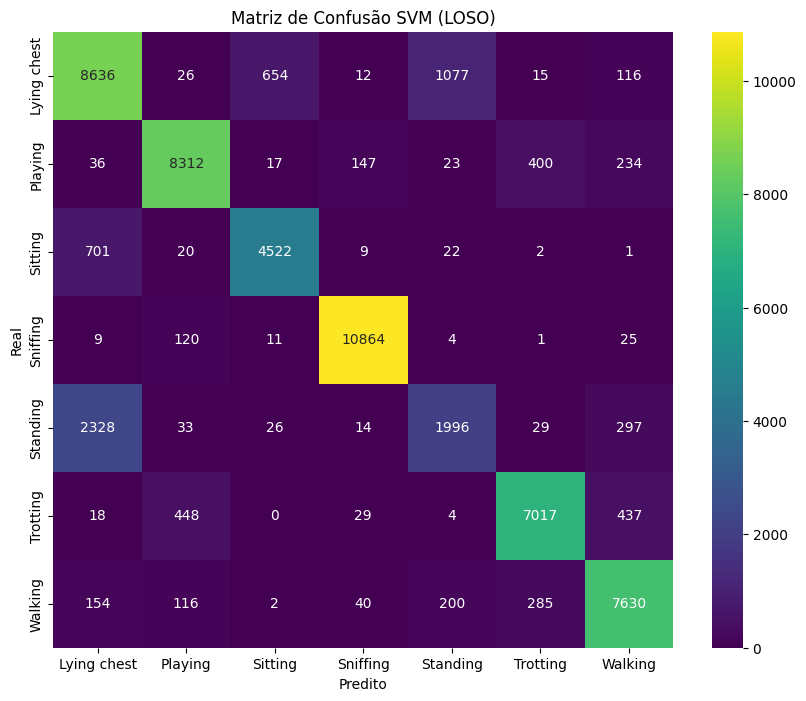

In [6]:
cm = confusion_matrix(y_encoded, y_pred_loso)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title(f'Matriz de Confusão SVM (LOSO)')
plt.show()

In [7]:
results_df = pd.DataFrame(grid_search.cv_results_)
cols_export = ['param_kernel', 'param_C', 'param_gamma', 'mean_test_score', 'rank_test_score']
output_csv = repo_root / "data" / "processed" / "svm_loso_results.csv"

output_csv.parent.mkdir(parents=True, exist_ok=True)

results_df[cols_export].sort_values(by='rank_test_score').to_csv(output_csv, index=False)
print(f"Tabela salva em: {output_csv}")

Tabela salva em: C:\Users\MatheusCadorin\git\classificacao-comportamento-canino-ine5687\data\processed\svm_loso_results.csv
